# Solution - LightGBM on Census Income (Adult)

Instructor solution for `adult_lightgbm.ipynb`. **LightGBM as one lens** (single tree /
random forest / gradient boosting from the same library), plus a **logistic-regression
baseline** for contrast, tuning, and a read + audit (importance, monotonic constraint,
subgroup slice-check by `sex`).

Run top to bottom with the `ma` kernel. `random_state = 509`. ~76% earn `<=50K`, so we report
**ROC-AUC and F1**, not accuracy.

**About the data.** UCI **Adult / "Census Income"** - one row per adult from the **1994 US
Census** (Becker & Kohavi); predict income **> \$50K/year** from demographics + work features.
~24% positive, with categorical features and missing values, and the canonical **fairness**
benchmark. Source: [UCI](https://archive.ics.uci.edu/dataset/2/adult) ·
[OpenML 1590](https://www.openml.org/d/1590).

In [3]:
%matplotlib inline
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score
from lightgbm import LGBMClassifier, early_stopping

SEED = 509
adult = fetch_openml('adult', version=2, as_frame=True)
df = adult.frame
print('raw shape:', df.shape)
df.head(3)

raw shape: (48842, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K


## Part 0 - Clean and explore

- **Target:** `y = (class == '>50K')`.
- **Drop** `fnlwgt` (a census *sampling weight*, not a predictor) and `education` (a string
  duplicate of the ordinal `education-num` - we keep the numeric one so we can put a monotonic
  constraint on it later).
- **Missing values** (`workclass`, `occupation`, `native-country`) stay as `NaN`: LightGBM
  handles them natively, no imputation needed.
- **Categoricals** keep the pandas `category` dtype - LightGBM reads them directly.
- One **stratified** split, reused everywhere.

In [4]:
y = (df['class'] == '>50K').astype(int)
X = df.drop(columns=['class', 'fnlwgt', 'education'])
cat_cols = X.select_dtypes('category').columns.tolist()
num_cols = X.select_dtypes('number').columns.tolist()

print(f"n = {len(X)},  features = {X.shape[1]}  ({len(cat_cols)} categorical, {len(num_cols)} numeric)")
print('positive (>50K) rate:', round(float(y.mean()), 3),
      '| always-<=50K accuracy:', round(float(1 - y.mean()), 3))
print('\nmissing values:')
print(X.isna().sum()[X.isna().sum() > 0].to_string())
print('\nnative-country levels:', X['native-country'].nunique())

X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.25, random_state=SEED, stratify=y)
print('\ntrain', X_tr.shape, 'test', X_te.shape)

n = 48842,  features = 12  (7 categorical, 5 numeric)
positive (>50K) rate: 0.239 | always-<=50K accuracy: 0.761

missing values:
workclass         2799
occupation        2809
native-country     857

native-country levels: 41

train (36631, 12) test (12211, 12)


**A quick look:** the positive rate climbs steadily with `education-num` - a near-monotone
signal we will lean on with a monotonic constraint in Part 3.

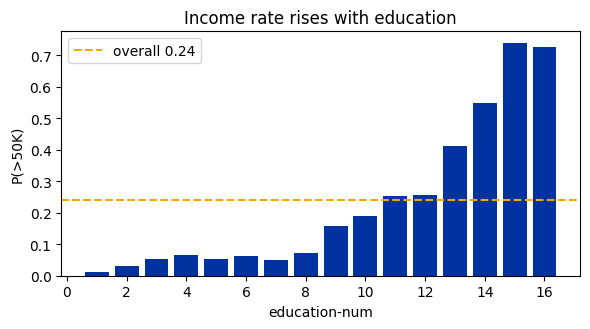

In [5]:
rate = pd.DataFrame({'ed': X['education-num'], 'y': y}).groupby('ed')['y'].mean()
plt.figure(figsize=(6, 3.4))
plt.bar(rate.index, rate.values, color='#0033A0')
plt.axhline(y.mean(), color='#F2A800', ls='--', label=f'overall {y.mean():.2f}')
plt.xlabel('education-num'); plt.ylabel('P(>50K)'); plt.legend()
plt.title('Income rate rises with education'); plt.tight_layout(); plt.show()

## Part 1 - Baselines: one library (+ a linear reference)

A running **scoreboard**. First the *non-tree* reference - **logistic regression** - which,
unlike the trees, cannot eat the raw frame: it needs **imputation + one-hot + scaling**. Then
the three tree ensembles, all from LightGBM on the *same raw frame*.

In [ ]:
from sklearn.metrics import precision_score, recall_score

scores = {}
def record(name, model):
    model.fit(X_tr, y_tr)
    proba = model.predict_proba(X_te)[:, 1]
    pred = (proba >= 0.5).astype(int)
    scores[name] = dict(auc=roc_auc_score(y_te, proba), f1=f1_score(y_te, pred),
                        acc=accuracy_score(y_te, pred), 
                        precision=precision_score(y_te, pred), recall=recall_score(y_te, pred))
    
    print(f"{name:24s} AUC={scores[name]['auc']:.3f}  F1={scores[name]['f1']:.3f}  "
          f"acc={scores[name]['acc']:.3f}, precision={scores[name]['precision']:.3f}, recall={scores[name]['recall']:.3f}")
    return model

# --- logistic-regression baseline: needs real preprocessing ---
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

pre = ColumnTransformer([
    ('num', Pipeline([('imp', SimpleImputer(strategy='median')),
                      ('sc', StandardScaler())]), num_cols),
    ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                      ('oh', OneHotEncoder(handle_unknown='ignore'))]), cat_cols)])
logreg = record('logistic regression', Pipeline([('pre', pre),
                                                 ('clf', LogisticRegression(max_iter=1000))]))



logistic regression      AUC=0.905  F1=0.661  acc=0.853, precision=0.737, recall=0.599


In [9]:
# --- three ensembles, one library, on the RAW frame (NaN + categoricals handled natively) ---
record('single tree (LGBM)', LGBMClassifier(
    n_estimators=1, learning_rate=1.0, random_state=SEED, verbose=-1, n_jobs=1))
record('random forest (LGBM)', LGBMClassifier(
    boosting_type='rf', bagging_fraction=0.8, bagging_freq=1, feature_fraction=0.8,
    n_estimators=300, random_state=SEED, verbose=-1, n_jobs=1))
record('gradient boosting (LGBM)', LGBMClassifier(
    random_state=SEED, verbose=-1, n_jobs=1))
print('\nOrdering: logreg ~ single tree < random forest < gradient boosting.')
print('A well-preprocessed linear model only matches ONE tree; boosting on the raw frame wins.')

single tree (LGBM)       AUC=0.902  F1=0.664  acc=0.858, precision=0.763, recall=0.587
random forest (LGBM)     AUC=0.914  F1=0.685  acc=0.864, precision=0.771, recall=0.617
gradient boosting (LGBM) AUC=0.929  F1=0.712  acc=0.874, precision=0.786, recall=0.650

Ordering: logreg ~ single tree < random forest < gradient boosting.
A well-preprocessed linear model only matches ONE tree; boosting on the raw frame wins.


**Native categoricals vs one-hot.** LightGBM can split on categories directly. One-hot encoding
`native-country` (41 levels) alone explodes the column count - for little or no gain, and slower.

In [12]:
def timed_fit_auc(Xtr, Xte, tag):
    t0 = time.perf_counter()
    m = LGBMClassifier(random_state=SEED, verbose=-1, n_jobs=1).fit(Xtr, y_tr)
    dt = time.perf_counter() - t0
    auc = roc_auc_score(y_te, m.predict_proba(Xte)[:, 1])
    print(f"{tag:16s} cols={Xtr.shape[1]:4d}  AUC={auc:.3f}  fit={dt:.2f}s")

timed_fit_auc(X_tr, X_te, 'native cats')
Xtr_oh = pd.get_dummies(X_tr, columns=cat_cols)
Xte_oh = pd.get_dummies(X_te, columns=cat_cols).reindex(columns=Xtr_oh.columns, fill_value=0)
timed_fit_auc(Xtr_oh, Xte_oh, 'one-hot')

native cats      cols=  12  AUC=0.929  fit=2.47s
one-hot          cols=  88  AUC=0.929  fit=2.41s


## Part 2 - Make the GBDT win (tuning)

Carve a **validation** slice out of train for early stopping and model selection; the **test**
set is touched only for the final number. First tune **by hand** in the [20] order
(`learning_rate` -> `num_leaves` / `min_data_in_leaf` -> regularization) to see *why* each knob
matters; then let **Optuna** (Bayesian TPE) search the whole space automatically and compare.

In [13]:
X_fit, X_val, y_fit, y_val = train_test_split(
    X_tr, y_tr, test_size=0.2, random_state=SEED, stratify=y_tr)

def fit_es(**params):
    m = LGBMClassifier(n_estimators=3000, random_state=SEED, verbose=-1, n_jobs=1, **params)
    m.fit(X_fit, y_fit, eval_set=[(X_val, y_val)], eval_metric='auc',
          callbacks=[early_stopping(50, verbose=False)])
    return m

def val_auc(m):
    return roc_auc_score(y_val, m.predict_proba(X_val)[:, 1])

# 1) learning rate (trees chosen by early stopping)
for lr in [0.02, 0.05, 0.1]:
    m = fit_es(learning_rate=lr)
    print(f"lr={lr:<5} best_iter={m.best_iteration_:4d}  val AUC={val_auc(m):.4f}")

lr=0.02  best_iter= 611  val AUC=0.9265
lr=0.05  best_iter= 236  val AUC=0.9265
lr=0.1   best_iter= 115  val AUC=0.9268


In [14]:
# 2) num_leaves / min_data_in_leaf, around the best learning rate
best = (None, 0.0, None)
for nl in [31, 63, 127]:
    for mdl_ in [20, 50, 100]:
        m = fit_es(learning_rate=0.05, num_leaves=nl, min_child_samples=mdl_)
        a = val_auc(m)
        if a > best[1]:
            best = ({'num_leaves': nl, 'min_child_samples': mdl_}, a, m)
print('best leaves/min_data:', best[0], 'val AUC', round(best[1], 4))

# 3) L1/L2 regularization on top
best_params = dict(learning_rate=0.05, **best[0])
for l1, l2 in [(0.0, 0.0), (1.0, 1.0), (5.0, 5.0)]:
    m = fit_es(reg_alpha=l1, reg_lambda=l2, **best_params)
    a = val_auc(m)
    print(f"reg_alpha={l1} reg_lambda={l2}  val AUC={a:.4f}")
    if a >= best[1]:
        best = ({**best[0], 'reg_alpha': l1, 'reg_lambda': l2}, a, m)
manual_params = dict(learning_rate=0.05, **best[0])
manual_auc = best[1]
print('\nmanual grid chose:', manual_params, '| val AUC', round(manual_auc, 4))

best leaves/min_data: {'num_leaves': 31, 'min_child_samples': 20} val AUC 0.9265
reg_alpha=0.0 reg_lambda=0.0  val AUC=0.9265
reg_alpha=1.0 reg_lambda=1.0  val AUC=0.9257
reg_alpha=5.0 reg_lambda=5.0  val AUC=0.9242

manual grid chose: {'learning_rate': 0.05, 'num_leaves': 31, 'min_child_samples': 20, 'reg_alpha': 0.0, 'reg_lambda': 0.0} | val AUC 0.9265


**The automated way: Bayesian search with Optuna.** The hand grid tried a handful of points; a
**Tree-structured Parzen Estimator (TPE)** proposes each next trial from the ones that worked so
far, exploring the *whole* space efficiently. Same validation-AUC objective, same early stopping
per trial. `optuna` ships in the course `ma` env.

In [15]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = dict(
        learning_rate=trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        num_leaves=trial.suggest_int('num_leaves', 15, 255),
        min_child_samples=trial.suggest_int('min_child_samples', 10, 200),
        reg_alpha=trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        reg_lambda=trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        feature_fraction=trial.suggest_float('feature_fraction', 0.5, 1.0),
        bagging_fraction=trial.suggest_float('bagging_fraction', 0.5, 1.0),
        bagging_freq=trial.suggest_int('bagging_freq', 1, 5),
    )
    return val_auc(fit_es(**params))

study = optuna.create_study(direction='maximize',
                            sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective, n_trials=40, show_progress_bar=False)

best_params = study.best_params                    # carry Optuna's pick forward as the tuned model
print(f"Optuna best val AUC = {study.best_value:.4f}   "
      f"(manual grid {manual_auc:.4f}, over {len(study.trials)} trials)")
print("best params:", {k: (round(v, 4) if isinstance(v, float) else v)
                       for k, v in best_params.items()})

c:\Users\hayk_\OneDrive\Desktop\01_python_math_ml_course\ma\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Optuna best val AUC = 0.9270   (manual grid 0.9265, over 40 trials)
best params: {'learning_rate': 0.0177, 'num_leaves': 50, 'min_child_samples': 39, 'reg_alpha': 0.0102, 'reg_lambda': 0.0863, 'feature_fraction': 0.6505, 'bagging_fraction': 0.9323, 'bagging_freq': 4}


In [16]:
# refit the tuned model on ALL of train (early stopping on val for the tree count), then record
tuned = fit_es(**best_params)
best_gbdt = LGBMClassifier(n_estimators=tuned.best_iteration_, random_state=SEED,
                           verbose=-1, n_jobs=1, **best_params)
record('tuned GBDT', best_gbdt)

tuned GBDT               AUC=0.930  F1=0.712  acc=0.874, precision=0.787, recall=0.651


,boosting_type,'gbdt'
,num_leaves,50
,max_depth,-1
,learning_rate,0.017669460712612217
,n_estimators,521
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,39


**Imbalance + threshold.** `scale_pos_weight` re-weights the minority (helps F1, leaves the
ranking/AUC ~unchanged). Then pick the **decision threshold by F1** on validation, not the
default 0.5.

In [17]:
spw = float((y_fit == 0).sum() / (y_fit == 1).sum())
print(spw)
bal = fit_es(scale_pos_weight=spw, **best_params)
auc_bal = roc_auc_score(y_te, bal.predict_proba(X_te)[:, 1])
f1_bal = f1_score(y_te, (bal.predict_proba(X_te)[:, 1] >= 0.5).astype(int))
print(f"scale_pos_weight={spw:.2f}: test AUC={auc_bal:.3f}  F1@0.5={f1_bal:.3f}  "
      f"(vs tuned AUC={scores['tuned GBDT']['auc']:.3f} F1={scores['tuned GBDT']['f1']:.3f})")

# threshold by F1 on the validation set, applied to test
pv = best_gbdt.predict_proba(X_val)[:, 1]
ths = np.linspace(0.1, 0.9, 81)
best_th = ths[int(np.argmax([f1_score(y_val, (pv >= t).astype(int)) for t in ths]))]
pt = best_gbdt.predict_proba(X_te)[:, 1]
print(f"best F1 threshold = {best_th:.2f}:  test F1 {f1_score(y_te,(pt>=0.5).astype(int)):.3f} "
      f"(@0.5) -> {f1_score(y_te,(pt>=best_th).astype(int)):.3f} (@{best_th:.2f})")

3.1791215059897318
scale_pos_weight=3.18: test AUC=0.919  F1@0.5=0.000  (vs tuned AUC=0.930 F1=0.712)
best F1 threshold = 0.43:  test F1 0.712 (@0.5) -> 0.727 (@0.43)


## Part 3 - Read it and audit it

**Gain vs permutation importance.** Gain (from train) leans on high-cardinality splits;
permutation (on test) says what actually moves the held-out score.

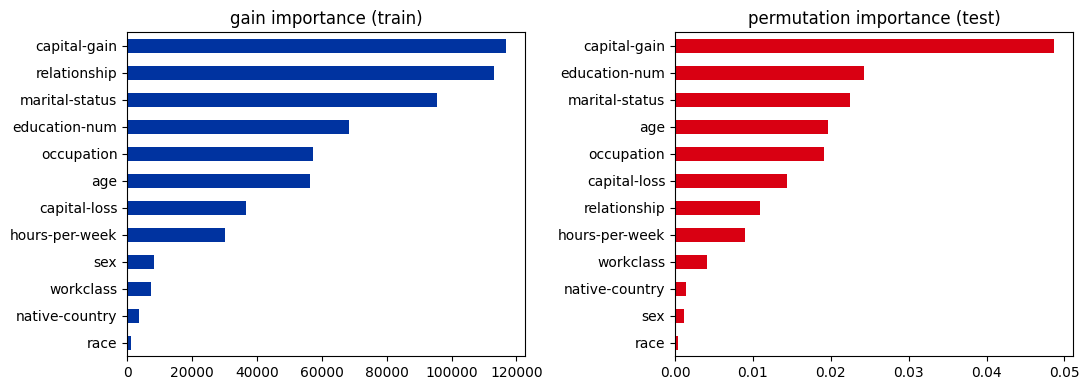

gain top-3     : ['capital-gain', 'relationship', 'marital-status']
permutation top-3: ['capital-gain', 'education-num', 'marital-status']


In [12]:
from sklearn.inspection import permutation_importance
gain = pd.Series(best_gbdt.booster_.feature_importance(importance_type='gain'),
                 index=X_tr.columns).sort_values(ascending=False)
perm = permutation_importance(best_gbdt, X_te, y_te, n_repeats=5,
                              random_state=SEED, n_jobs=1)
perm = pd.Series(perm.importances_mean, index=X_tr.columns).sort_values(ascending=False)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
gain.iloc[::-1].plot.barh(ax=ax[0], color='#0033A0'); ax[0].set_title('gain importance (train)')
perm.iloc[::-1].plot.barh(ax=ax[1], color='#D90012'); ax[1].set_title('permutation importance (test)')
plt.tight_layout(); plt.show()
print('gain top-3     :', list(gain.index[:3]))
print('permutation top-3:', list(perm.index[:3]))

### Linear vs non-linear: which features have a non-linear effect?

Logistic regression can only use a **numeric** feature through a **linear, monotone** effect. If
gradient boosting extracts far more from a numeric feature than logreg does, the extra signal is
exactly what a line cannot represent - **curvature or a non-monotone shape**. So we compare
**permutation importance** (drop in test ROC-AUC) for both models: a large **gbdt - logreg gap**
on a numeric feature flags non-linearity.

*Reading a numeric gap:* it can come from **curvature / non-monotonicity** *or* from
**interactions** with other features - additive logreg captures neither. The
**partial-dependence plot disambiguates**: a clearly curved or non-monotone univariate PDP
(like `age`) is curvature; a flat PDP despite a large gap would instead point to interactions.

*Caveat:* for **categorical** features the one-hot logreg already fits an arbitrary per-level
effect, so it is not linearity-limited there - a categorical gap means **interactions or
redundancy**, not univariate curvature. Read the *numeric* rows for the non-linearity story.

In [13]:
imp_lr = permutation_importance(logreg, X_te, y_te, scoring='roc_auc',
                                n_repeats=5, random_state=SEED, n_jobs=1).importances_mean
imp_gb = permutation_importance(best_gbdt, X_te, y_te, scoring='roc_auc',
                                n_repeats=5, random_state=SEED, n_jobs=1).importances_mean
gap = pd.DataFrame({'logreg': imp_lr, 'gbdt': imp_gb}, index=X_tr.columns)
gap['gap'] = gap['gbdt'] - gap['logreg']
gap['kind'] = ['numeric' if c in num_cols else 'categorical' for c in X_tr.columns]
print(gap.sort_values('gap', ascending=False).round(4).to_string())
print("\nBiggest positive gaps are NUMERIC (age, capital-gain): boosting sees a shape logreg"
      " cannot. education-num has ~zero/negative gap, so its effect is essentially linear.")

                logreg    gbdt     gap         kind
age             0.0061  0.0493  0.0432      numeric
capital-gain    0.0328  0.0582  0.0254      numeric
capital-loss    0.0057  0.0175  0.0118      numeric
hours-per-week  0.0090  0.0129  0.0039      numeric
relationship    0.0099  0.0132  0.0032  categorical
race            0.0004  0.0004  0.0001  categorical
workclass       0.0025  0.0025 -0.0000  categorical
native-country  0.0016  0.0013 -0.0003  categorical
occupation      0.0192  0.0162 -0.0030  categorical
sex             0.0071  0.0013 -0.0059  categorical
education-num   0.0358  0.0256 -0.0102      numeric
marital-status  0.1444  0.0357 -0.1087  categorical

Biggest positive gaps are NUMERIC (age, capital-gain): boosting sees a shape logreg cannot. education-num has ~zero/negative gap, so its effect is essentially linear.


C:\Users\hayk_\OneDrive\Desktop\01_python_math_ml_course\ma\Lib\site-packages\sklearn\inspection\_partial_dependence.py:717: FutureWarning: The column 0 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


C:\Users\hayk_\OneDrive\Desktop\01_python_math_ml_course\ma\Lib\site-packages\sklearn\inspection\_partial_dependence.py:717: FutureWarning: The column 8 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


C:\Users\hayk_\OneDrive\Desktop\01_python_math_ml_course\ma\Lib\site-packages\sklearn\inspection\_partial_dependence.py:717: FutureWarning: The column 2 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


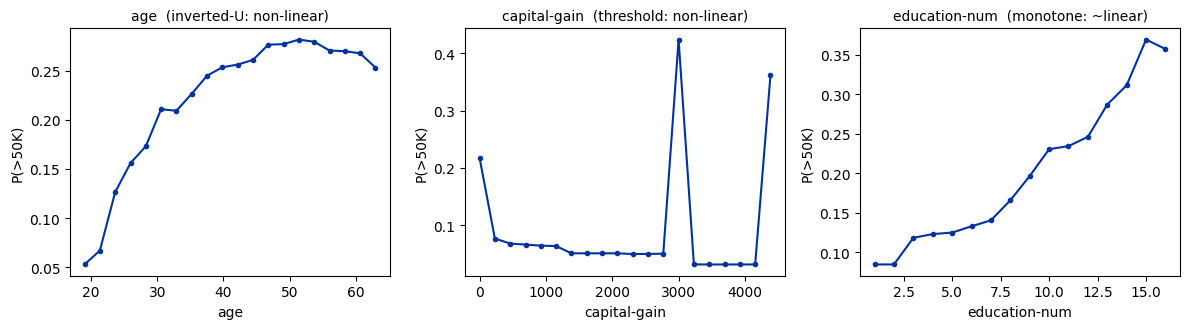

PDPs confirm the gap: age peaks then declines, capital-gain jumps at a threshold (both non-linear); education-num rises monotonically (linear, so logreg already gets it).


In [14]:
from sklearn.inspection import partial_dependence
titles = {'age': 'age  (inverted-U: non-linear)',
          'capital-gain': 'capital-gain  (threshold: non-linear)',
          'education-num': 'education-num  (monotone: ~linear)'}
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))
for ax, f in zip(axes, titles):
    j = list(X_tr.columns).index(f)
    p = partial_dependence(best_gbdt, X_te, [j], grid_resolution=20, kind='average')
    ax.plot(p['grid_values'][0], p['average'][0], '-o', ms=3, color='#0033A0')
    ax.set_xlabel(f); ax.set_ylabel('P(>50K)'); ax.set_title(titles[f], fontsize=10)
plt.tight_layout(); plt.show()
print("PDPs confirm the gap: age peaks then declines, capital-gain jumps at a threshold "
      "(both non-linear); education-num rises monotonically (linear, so logreg already gets it).")

**Monotonic constraint on `education-num`.** We saw income rise with education; force the model
to respect that (non-decreasing). It costs at most a hair of AUC and makes the response sensible.

In [15]:
constr = [1 if c == 'education-num' else 0 for c in X_tr.columns]
mono = LGBMClassifier(n_estimators=best_gbdt.n_estimators, monotone_constraints=constr,
                      random_state=SEED, verbose=-1, n_jobs=1, **best_params).fit(X_tr, y_tr)
print(f"AUC  unconstrained={scores['tuned GBDT']['auc']:.3f}  "
      f"monotone(education-num)={roc_auc_score(y_te, mono.predict_proba(X_te)[:,1]):.3f}")

AUC  unconstrained=0.930  monotone(education-num)=0.930


**Subgroup slice-check by `sex` and `race`.** A strong overall AUC can hide very different
per-group behavior. Adult is *the* canonical fairness benchmark, so we split the test set by
**`sex`** and **`race`** and report per-group ROC-AUC and predicted-positive rate.

In [16]:
from collections import Counter
proba_te = best_gbdt.predict_proba(X_te)[:, 1]
yv = y_te.values
print(f"overall: AUC={roc_auc_score(yv, proba_te):.3f}  "
      f"pred>50K={(proba_te>=best_th).mean():.3f}  true>50K={yv.mean():.3f}")

def slice_report(col):
    vals = X_te[col].astype(str).values
    print(f"\n== by {col} ==")
    for g, _ in Counter(vals).most_common():
        mask = vals == g
        if mask.sum() < 40 or len(np.unique(yv[mask])) < 2:
            continue
        print(f"  {g:20s} n={mask.sum():5d}  AUC={roc_auc_score(yv[mask], proba_te[mask]):.3f}  "
              f"pred>50K={(proba_te[mask]>=best_th).mean():.3f}  true>50K={yv[mask].mean():.3f}")

slice_report('sex')
slice_report('race')

overall: AUC=0.930  pred>50K=0.226  true>50K=0.239

== by sex ==
  Male                 n= 8091  AUC=0.913  pred>50K=0.295  true>50K=0.306
  Female               n= 4120  AUC=0.948  pred>50K=0.092  true>50K=0.108

== by race ==
  White                n=10423  AUC=0.927  pred>50K=0.243  true>50K=0.252
  Black                n= 1174  AUC=0.954  pred>50K=0.095  true>50K=0.125
  Asian-Pac-Islander   n=  408  AUC=0.916  pred>50K=0.265  true>50K=0.299
  Amer-Indian-Eskimo   n=  110  AUC=0.946  pred>50K=0.091  true>50K=0.136
  Other                n=   96  AUC=1.000  pred>50K=0.062  true>50K=0.073


In [19]:
from time import sleep
sleep(30)
print(1)

1


**Reflection.**

- **Did tree < RF < GBDT hold?** Yes. A single tree (~0.90 AUC) is roughly matched by the
  well-preprocessed **logistic regression** baseline; the **random forest** improves on it, and
  **gradient boosting** wins clearly (~0.93). Tuning adds a further small bump.
- **Where did tuning help most?** `learning_rate` + early stopping (the tree count), then
  `num_leaves` / `min_child_samples` to control complexity. Regularization gave little here.
  **Optuna's TPE search** over the same space matched (or slightly beat) the hand grid, for far
  less manual effort - the way you would actually tune in practice.
- **Categoricals:** native handling matched one-hot on AUC with **far fewer columns** and faster
  fits - one-hot's only effect was to blow up the width via `native-country`.
- **Imbalance & threshold:** `scale_pos_weight` left AUC alone (it is threshold-independent) but,
  with an F1-chosen threshold, improved F1 - the operating point, not the ranking, was the lever.
- **Audit & fairness:** gain and permutation importance broadly agree on the top drivers
  (`marital-status`/`relationship`, `capital-gain`, `education-num`, `age`). The **slice-check**
  shows the model predicts `>50K` far more often for **men than women**, and unevenly **across
  race** groups - real disparities to weigh before deploying such a model (Adult is a standard
  fairness benchmark for exactly this reason).
- **Linear vs non-linear:** comparing logreg and GBDT permutation importance, the biggest gaps
  are on `age` and `capital-gain` - their partial-dependence curves are an inverted-U and a
  threshold, non-linear shapes a linear model cannot fit, which is a good chunk of why boosting
  beats the logreg baseline. `education-num` is essentially linear (no gap), and the categorical
  gaps reflect encoding/interactions, not curvature.
- **Next:** try XGBoost / CatBoost, calibrate the probabilities ([14]), and add a stacking layer.

## Scoreboard

In [17]:
board = pd.DataFrame(scores).T[['auc', 'f1', 'acc']].round(3)
print(board.to_string())
board

                            auc     f1    acc
logistic regression       0.905  0.661  0.853
single tree (LGBM)        0.902  0.664  0.858
random forest (LGBM)      0.914  0.685  0.864
gradient boosting (LGBM)  0.929  0.712  0.874
tuned GBDT                0.930  0.712  0.874


,auc,f1,acc
logistic regression,0.905,0.661,0.853
single tree (LGBM),0.902,0.664,0.858
random forest (LGBM),0.914,0.685,0.864
gradient boosting (LGBM),0.929,0.712,0.874
tuned GBDT,0.930,0.712,0.874
